Task 1: Verify your Google Cloud environment setup, including capturing proof of your active cloud notebook instance or billing credit balance.

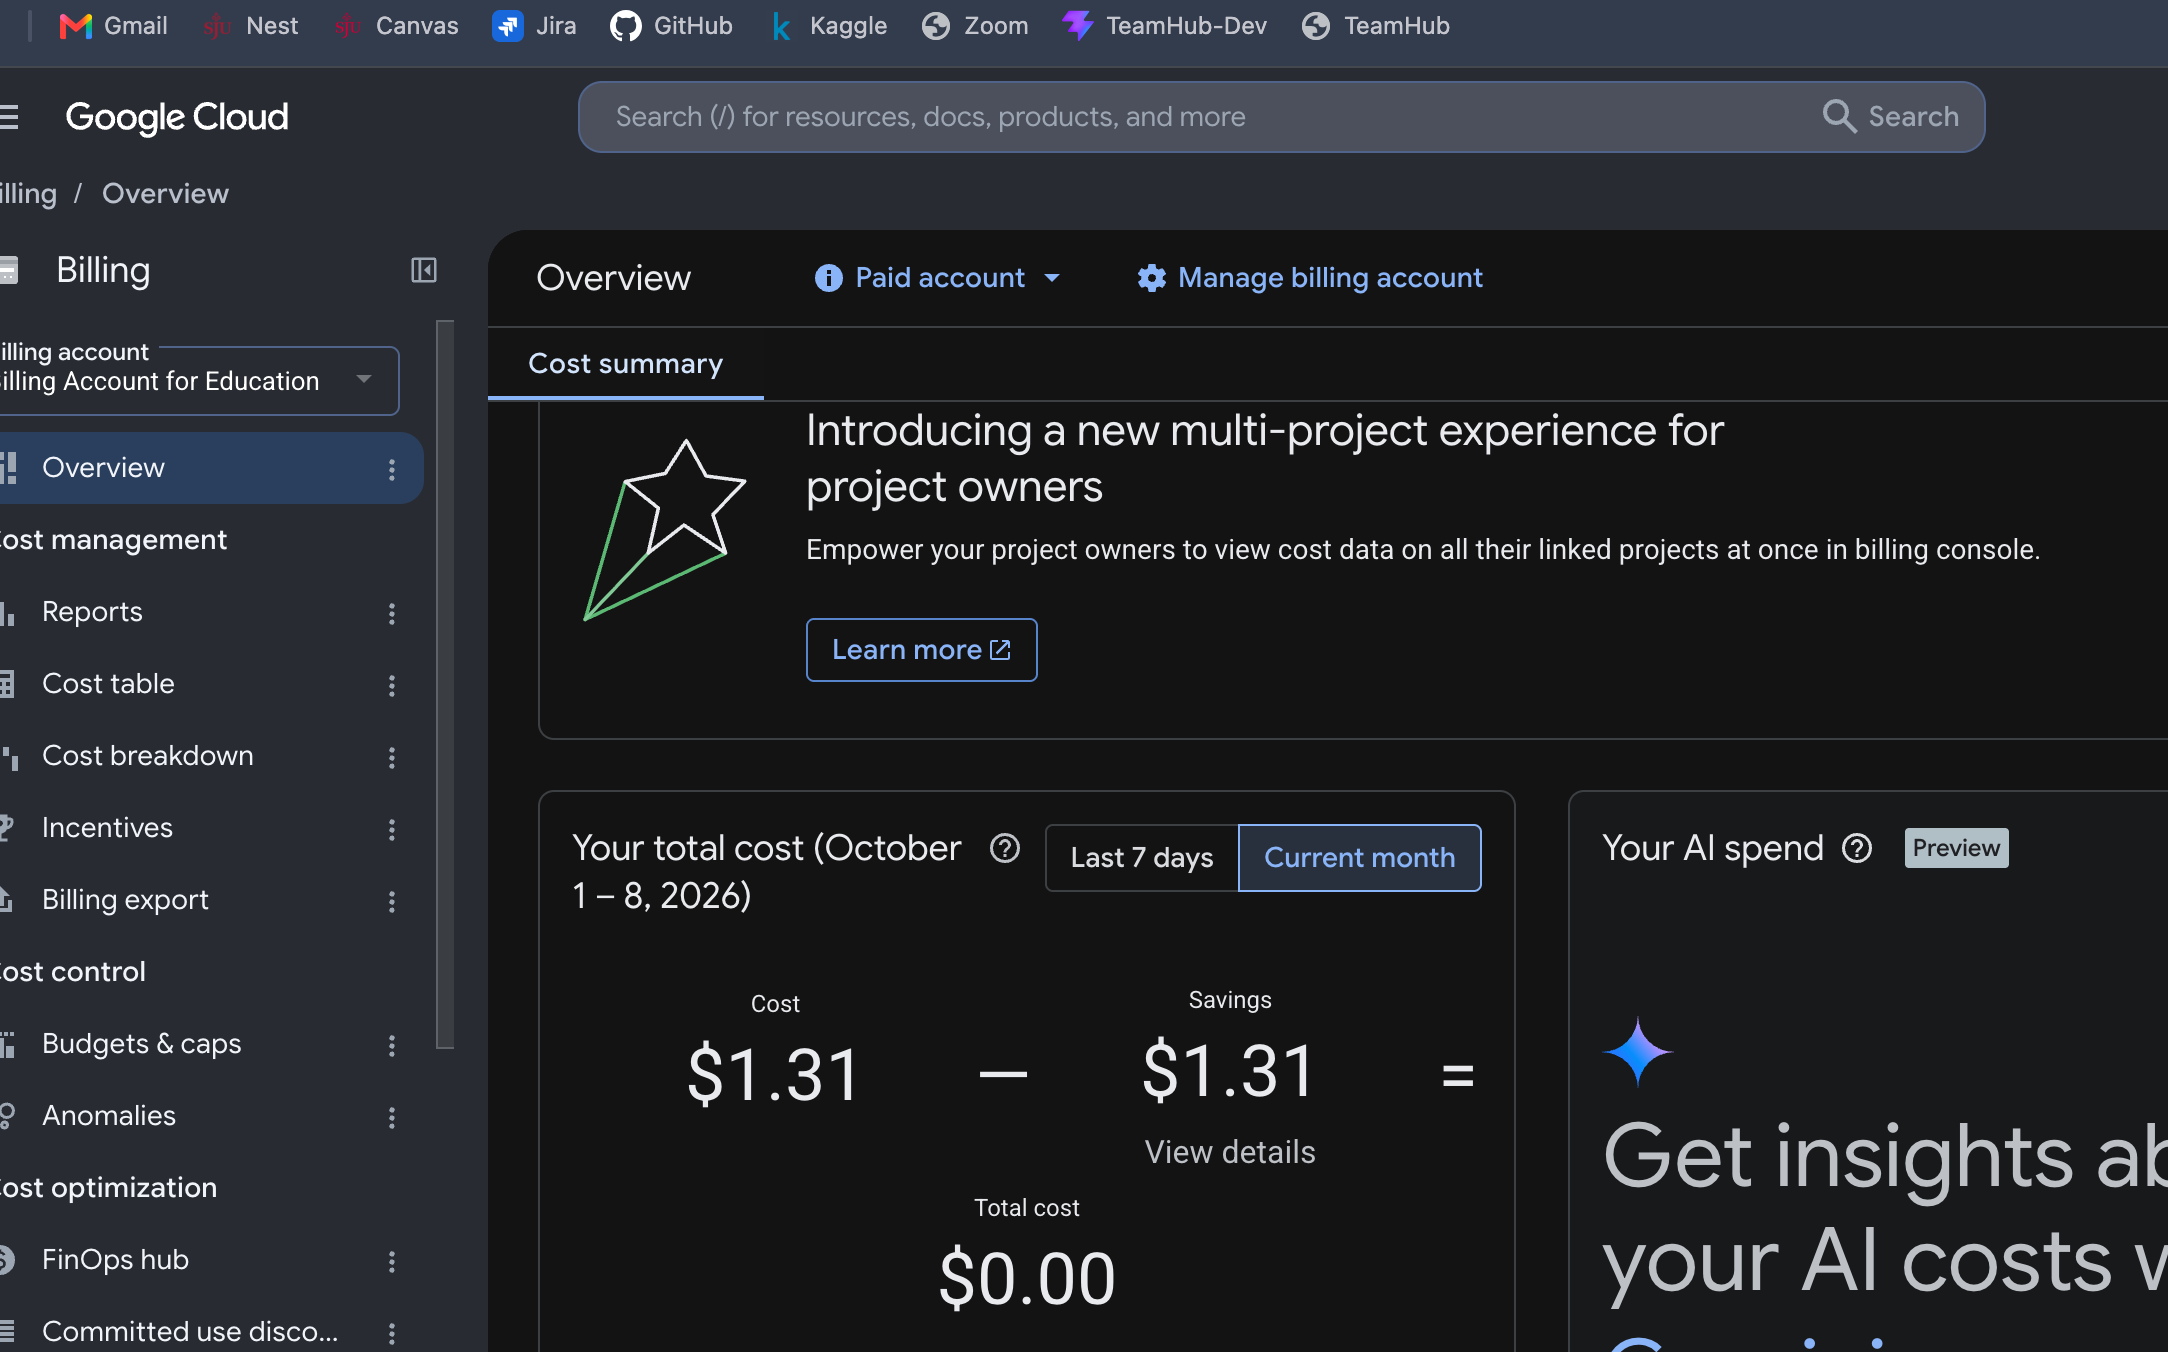

Task 2: Load the dataset into a Pandas DataFrame using the official ucimlrepo package or direct data retrieval methods linked to the UCI repository (https://archive.ics.uci.edu/dataset/360/air+qualityLinks to an external site.).

In [85]:
#!pip install ucimlrepo

import pandas as pd
import numpy as np
from ucimlrepo import fetch_ucirepo

# Import from ucimlrepo
aq = fetch_ucirepo(id=360)
df = aq.data.features.copy()

Task 3: Use structural inspection methods (head(), info(), describe()) to analyze the dataset structure and examine feature distributions across sensor and meteorological variables.


In [86]:
# Display Data Frame Head
print("\n --- DF Head ---")
print(df.head())

# Display Data Frame Info
print("\n --- DF INFO ---")
df.info()


 --- DF Head ---
        Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  3/10/2004  18:00:00     2.6         1360       150      11.9   
1  3/10/2004  19:00:00     2.0         1292       112       9.4   
2  3/10/2004  20:00:00     2.2         1402        88       9.0   
3  3/10/2004  21:00:00     2.2         1376        80       9.2   
4  3/10/2004  22:00:00     1.6         1272        51       6.5   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0           1046      166          1056      113          1692         1268   
1            955      103          1174       92          1559          972   
2            939      131          1140      114          1555         1074   
3            948      172          1092      122          1584         1203   
4            836      131          1205      116          1490         1110   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  
3  11.0 

In [87]:
# Create Object Columns
obj_cols = df.select_dtypes(include="object").columns.tolist()
print("\n --- OBJ Summary Statistics ---")
display(df[obj_cols].describe())

# Create Number Columns
num_cols = df.select_dtypes(include="number").columns.tolist()
print("\n --- NUM Summary Statistics ---")
display(df[num_cols].describe())


 --- OBJ Summary Statistics ---


,Date,Time
count,9357,9357
unique,391,24
top,4/3/2005,18:00:00
freq,24,390



 --- NUM Summary Statistics ---


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,-34.207524,1048.990061,-159.090093,1.865683,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,9.778305,39.485380,-6.837604
std,77.657170,329.832710,139.789093,41.380206,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,43.203623,51.216145,38.976670
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,0.600000,921.000000,-200.000000,4.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,10.900000,34.100000,0.692300
50%,1.500000,1053.000000,-200.000000,7.900000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,17.200000,48.600000,0.976800
75%,2.600000,1221.000000,-200.000000,13.600000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,24.100000,61.900000,1.296200
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


Task 4: Identify and handle implicit missing data values (such as the standard -200 sentinel values present in the air quality dataset) and implement a structured imputation strategy using Scikit-Learn's SimpleImputer.

In [88]:
from sklearn.impute import SimpleImputer

# Count -200 values in numerical columns
print("--- Missing Values (-200) ---")
print((df[num_cols] == -200).sum())

df = df.replace(-200, np.nan)

# Remove completely empty columns
df = df.dropna(axis=1, how="all")

# Display missing value counts
print("--- Missing Values After Replacement ---")
print(df.isnull().sum())

--- Missing Values (-200) ---
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64
--- Missing Values After Replacement ---
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64


In [89]:
# Drop NMHC(GT) due to over 8000 missing vlaues
df = df.drop(columns=["NMHC(GT)"])

# Get Updated Cols After Clean
num_cols = df.select_dtypes(include="number").columns.tolist()
obj_cols = df.select_dtypes(include="object").columns.tolist()

# Create SimpleImputers
imputer_median = SimpleImputer(strategy="median")
imputer_constant = SimpleImputer(strategy='constant', fill_value = 'Unknown')

# Apply imputation
df[num_cols] = imputer_median.fit_transform(df[num_cols])
df[obj_cols] = imputer_constant.fit_transform(df[obj_cols])

# Display missing value counts
print("--- Missing Values After Replacement ---")
print(df.isnull().sum())

--- Missing Values After Replacement ---
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


Task 5: Isolate numerical and categorical features, then build a Scikit-Learn ColumnTransformer and Pipeline that applies appropriate scaling (StandardScaler or MinMaxScaler) to numerical columns and necessary encoding to categorical/temporal features.

In [90]:
# Import Libs
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline

X = df.drop(columns=['CO(GT)', "Date", "Time"])

num_data = X.select_dtypes(include=['int64', 'float64'])
cat_data = X.select_dtypes(include=['object'])

num_pipeline = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler())

cat_pipeline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore"))

preprocessing = ColumnTransformer([
    ("num", num_pipeline, num_data.columns.tolist()),
    ("cat", cat_pipeline, cat_data.columns.tolist()),
])

Task 6: Train classification models to predict air quality categories using standard logistic/softmax regression and an SGDClassifier configured with custom loss functions and hyperparameters, evaluating convergence speed and performance.

In [91]:
from sklearn.linear_model import SGDClassifier

# Create air quality Categories
df['Air_Quality'] = pd.qcut(df['CO(GT)'], q=3, labels=[0, 1, 2])

# Display category counts
print(df["Air_Quality"].value_counts())

Air_Quality
0    3175
2    3110
1    3072
Name: count, dtype: int64


In [92]:
import time
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = df["Air_Quality"]
X = df.drop(columns=["Air_Quality", "CO(GT)"])

# Split into Training Sets
# 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

def fit_pipeline(clf):
    pipeline = make_pipeline(preprocessing, clf)
    t = time.time()
    pipeline.fit(X_train, y_train)
    fit_time = time.time() - t
    pred = pipeline.predict(X_test)
    return pipeline

# Log Regression
print ("\n--- Logistic Regression ---")
log_pipe = fit_pipeline(LogisticRegression(random_state=42))
print(classification_report(y_test, log_pipe.predict(X_test)))

# Softmax Regression
print ("\n--- Softmax Regression ---")
softmax_pipe = fit_pipeline(LogisticRegression(C=30, max_iter=1000, random_state=42))
print(classification_report(y_test, softmax_pipe.predict(X_test)))

# Custom SGD
print ("\n--- Custom SGD ---")
sgd_pipe = fit_pipeline(SGDClassifier(loss='log_loss', random_state=42))
print(classification_report(y_test, sgd_pipe.predict(X_test)))


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       655
           1       0.68      0.69      0.68       592
           2       0.88      0.84      0.86       625

    accuracy                           0.79      1872
   macro avg       0.79      0.79      0.79      1872
weighted avg       0.79      0.79      0.79      1872


--- Softmax Regression ---
              precision    recall  f1-score   support

           0       0.80      0.84      0.82       655
           1       0.68      0.68      0.68       592
           2       0.88      0.85      0.87       625

    accuracy                           0.79      1872
   macro avg       0.79      0.79      0.79      1872
weighted avg       0.79      0.79      0.79      1872


--- Custom SGD ---
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       655
           1       0.68      0.58      0.63       59

Task 7: Transition to regression tasks to predict continuous pollutant concentrations, implementing baseline Linear Regression alongside Ridge (L2) and Lasso (L1) regularization, and analyzing how the regularization parameter impacts feature coefficients and feature selection.

In [93]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error

# Create new 80/20 Split for Linear Regression
y_reg = df["CO(GT)"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Linear Regression
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(X_train, y_train)
lin_pred = lin_reg.predict(X_test)

# Compute error metrics
mse = mean_squared_error(y_test, lin_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lin_pred)

print("--- Evaluation Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2:.4f}")

--- Evaluation Metrics ---
Mean Squared Error (MSE): 0.3246
Root Mean Squared Error (RMSE): 0.5697
R-squared (R2): 0.8269


In [94]:
# List of different Alphas to test
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

# For loop to complute Ridge/Lasso Regularization with different Alphas
for i in alphas:

    # Compute Ridge Regularization
    ridge_reg = make_pipeline(preprocessing, Ridge(alpha = i)).fit(X_train, y_train)
    ridge_r2 = r2_score(y_test, ridge_reg.predict(X_test))

    # Compute Lasso Regularization
    lasso_reg = make_pipeline(preprocessing, Lasso(alpha = i, max_iter=10000)).fit(X_train, y_train)
    lasso_r2 = r2_score(y_test, lasso_reg.predict(X_test))

    print ("\nalpha:  ", i)
    print (f"Ridge R2: {ridge_r2: .5f}")
    print (f"Lasso R2: {lasso_r2: .5f}")


alpha:   0.001
Ridge R2:  0.82695
Lasso R2:  0.82619

alpha:   0.01
Ridge R2:  0.82695
Lasso R2:  0.82150

alpha:   0.1
Ridge R2:  0.82695
Lasso R2:  0.79174

alpha:   1
Ridge R2:  0.82692
Lasso R2:  0.06546

alpha:   10
Ridge R2:  0.82666
Lasso R2: -0.00009

alpha:   100
Ridge R2:  0.82458
Lasso R2: -0.00009


Task 8: Provide a final documentation cell or appendix section containing a screenshot or export of your Google Cloud billing or resource utilization dashboard showing active credit consumption.

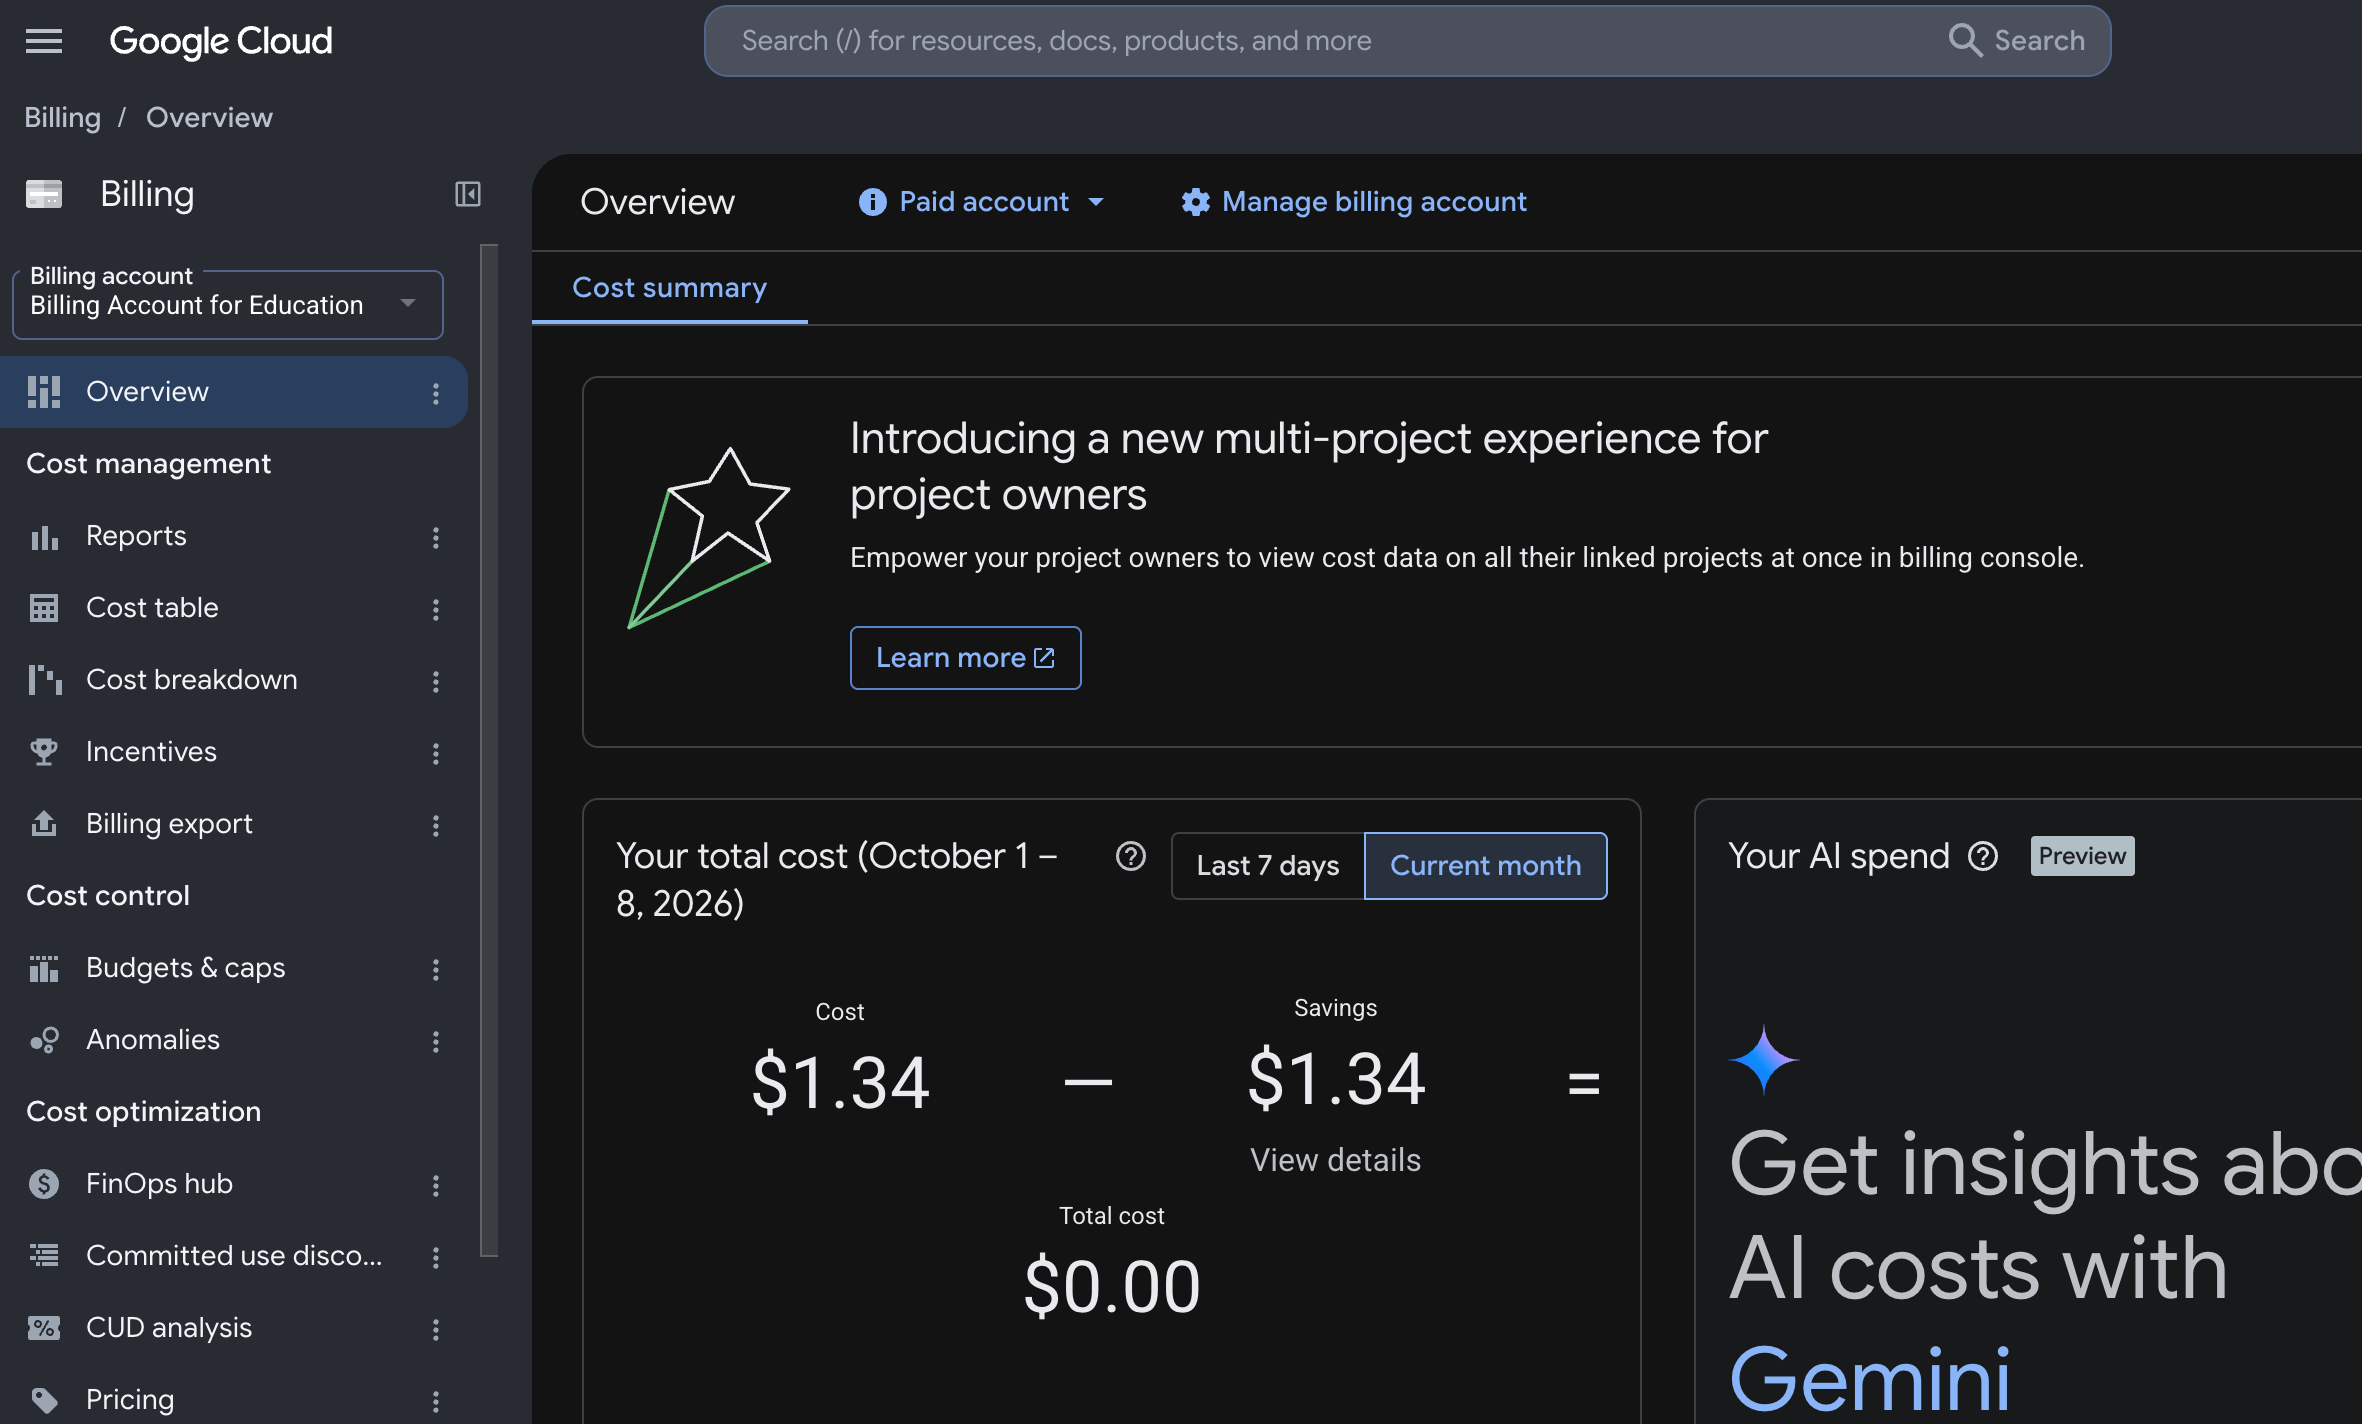